In [21]:
import numpy as np
from scipy.linalg import expm
from free_fermion_methods_cov import *
import matplotlib.pyplot as plt
from tqdm import tqdm

In [22]:
def generate_critical_ising_state(n, g, pbc = True):
    '''
    XX + g*Z
    '''
    h = np.zeros((2*n, 2*n), float)
    for ii in range(n-1):
        h[2 * ii, 2 * ii + 1] = g
        h[2 * ii + 1, 2 * ii + 2] = 1
    h[2*n-2, 2*n-1] = 1
    
    if pbc:
        h[2*n-1, 0] = 1
    
    h = h - h.T
    return h


def evolution_operator(h, t):
    return expm(4*h*t)

In [31]:
L = 8
dt = 0.001
O = evolution_operator(generate_critical_ising_state(L, 2), dt)

state = product_0_FGS(L)

ev = [0]
null = [0]
nstab = [0]
t = [0]
for ii in tqdm(range(1000)):

    state.apply_U_global(O)
    ev.append(quadratic_Tsallis_entropy(state, 2))
    nstab.append(stabilizer_Renyi_entropy_exact(state))
    t.append(t[-1] + dt)



100%|███████████████████████████████████████| 1000/1000 [16:14<00:00,  1.03it/s]


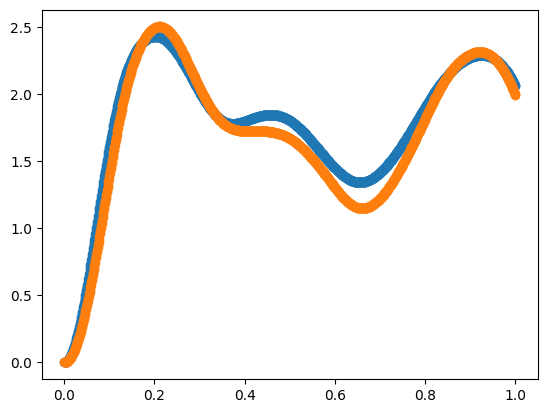

In [34]:
plt.plot(t, np.array(ev)/4, "-o")
plt.plot(t, nstab, "-o")
# plt.plot(null)
plt.show()

In [52]:
L = 512
dt = 0.01
O = evolution_operator(generate_critical_ising_state(L, 2), dt)

state = product_0_FGS(L)

ev = [0]
null = [0]
nstab = [0]
ent = [0]
t = [0]
for ii in tqdm(range(1000)):

    state.apply_U_global(O)
    ev.append(quadratic_Tsallis_entropy(state, 2))
    ent.append(state.compute_entanglement_entropy(L//2))
    # nstab.append(stabilizer_Renyi_entropy_exact(state))
    t.append(t[-1] + dt)



100%|███████████████████████████████████████| 1000/1000 [01:01<00:00, 16.26it/s]


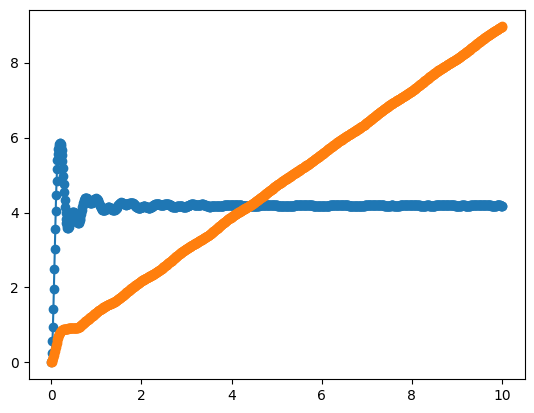

In [55]:
plt.plot(t, np.array(ev)/100, "-o")
plt.plot(t, np.array(ent), "-o")
# plt.plot(t, nstab, "-o")
# plt.plot(null)
plt.show()

In [38]:
L = 128
dt = 0.001
O = evolution_operator(generate_critical_ising_state(L, 2), dt)

state = product_0_FGS(L)

ev2 = [0]
null = [0]
nstab = [0]
t = [0]
for ii in tqdm(range(1000)):

    state.apply_U_global(O)
    ev2.append(quadratic_Tsallis_entropy(state, 2))
    # nstab.append(stabilizer_Renyi_entropy_exact(state))
    t.append(t[-1] + dt)



100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 851.20it/s]


In [39]:
L = 256
dt = 0.001
O = evolution_operator(generate_critical_ising_state(L, 2), dt)

state = product_0_FGS(L)

ev3 = [0]
null = [0]
nstab = [0]
t = [0]
for ii in tqdm(range(1000)):

    state.apply_U_global(O)
    ev3.append(quadratic_Tsallis_entropy(state, 2))
    # nstab.append(stabilizer_Renyi_entropy_exact(state))
    t.append(t[-1] + dt)



100%|██████████████████████████████████████| 1000/1000 [00:05<00:00, 187.88it/s]


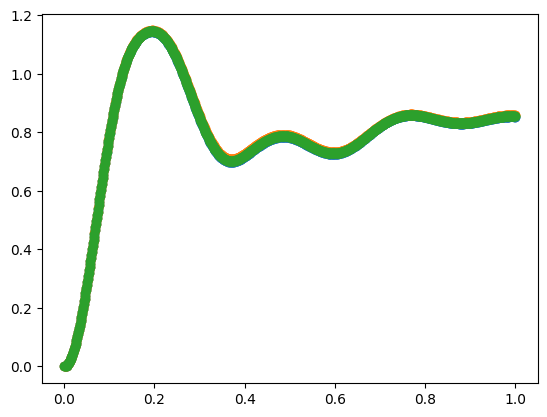

In [51]:
plt.plot(t, np.array(ev)/512, "-o")
plt.plot(t, np.array(ev2)/128, "-o")
plt.plot(t, np.array(ev3)/256, "-o")
# plt.plot(t, nstab, "-o")
# plt.plot(null)
plt.show()